## Driver Drowsiness Detection
## MLP Training Code

### Libraries

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
import joblib

### Load Dataset

In [24]:

# Load and Filter
df = pd.read_csv("./Dataset/MLP_Dataset/MLP_raw_v2.csv")


In [25]:
# ------------------ CLEANING ------------------
# Remove rows where Driver_State is missing

df = df[df["Label"].isin(["alert", "microsleep", "yawning"])].dropna()

### Features & Label

In [26]:
X = df[["EAR", "MAR"]]
y = df["Label"]

### Encode Lables

In [27]:
# Encode and Scale
le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train-Test Split

In [28]:
# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

### MLP Classifier

In [29]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

## Test Confusion Matrix


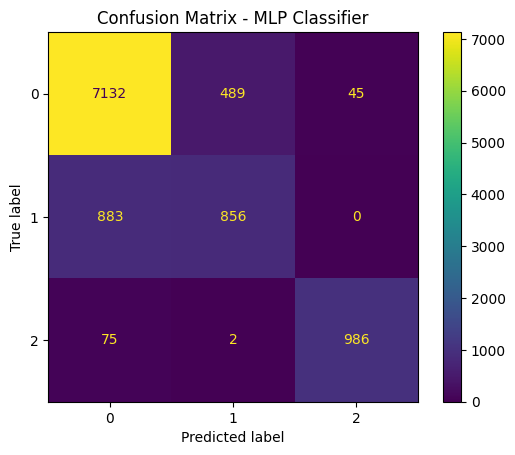

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict test data
y_pred = mlp.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp.classes_)

disp.plot()
plt.title("Confusion Matrix - MLP Classifier")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


## Train Confusion Matrix

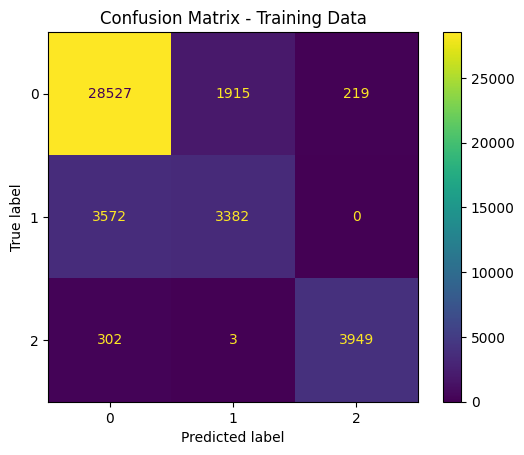

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on training data
y_train_pred = mlp.predict(X_train)

# Confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=mlp.classes_)
disp.plot()

plt.title("Confusion Matrix - Training Data")
plt.savefig("confusion_matrix1.png", dpi=300, bbox_inches='tight')
plt.show()

## Train Metrics

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

# Predict on training data
y_train_pred = mlp.predict(X_train)

# Metrics
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred, average='weighted')
sensitivity = recall_score(y_train, y_train_pred, average='weighted')  # Recall = Sensitivity
f1 = f1_score(y_train, y_train_pred, average='weighted')
mcc = matthews_corrcoef(y_train, y_train_pred)

# Specificity (manual calculation)
cm = confusion_matrix(y_train, y_train_pred)
tn = cm.sum() - (cm.sum(axis=1) + cm.sum(axis=0) - np.diag(cm))
fp = cm.sum(axis=0) - np.diag(cm)
specificity = (tn / (tn + fp)).mean()

# Table
train_metrics_df = pd.DataFrame({
    "Metrics": ["Accuracy", "Precision", "Sensitivity", "Specificity", "F1-Score", "MCC"],
    "Values": [accuracy, precision, sensitivity, specificity, f1, mcc]
})

print(train_metrics_df)
train_metrics_df.to_csv("train_metrics.csv", index=False)

       Metrics    Values
0     Accuracy  0.856433
1    Precision  0.846998
2  Sensitivity  0.856433
3  Specificity  0.864533
4     F1-Score  0.849500
5          MCC  0.646940


## Test metrics 

In [39]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

# Predict on test data
y_test_pred = mlp.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
sensitivity = recall_score(y_test, y_test_pred, average='weighted')  # Recall = Sensitivity
f1 = f1_score(y_test, y_test_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_test_pred)

# Specificity (manual calculation)
cm = confusion_matrix(y_test, y_test_pred)
tn = cm.sum() - (cm.sum(axis=1) + cm.sum(axis=0) - np.diag(cm))
fp = cm.sum(axis=0) - np.diag(cm)
specificity = (tn / (tn + fp)).mean()

# Table
test_metrics_df = pd.DataFrame({
    "Metrics": ["Accuracy", "Precision", "Sensitivity", "Specificity", "F1-Score", "MCC"],
    "Values": [accuracy, precision, sensitivity, specificity, f1, mcc]
})
test_metrics_df.to_csv("test_metrics.csv", index=False)
print(test_metrics_df)

       Metrics    Values
0     Accuracy  0.857279
1    Precision  0.848292
2  Sensitivity  0.857279
3  Specificity  0.865689
4     F1-Score  0.850772
5          MCC  0.649236


### Save the Model

In [10]:
# Save
joblib.dump(mlp, "./Models/mlp_model_v2.pkl")
joblib.dump(scaler, "./Models/scaler_v2.pkl")
joblib.dump(le, "./Models/label_map_v2.pkl")

print("✅ STEP 2 DONE: Model trained and saved.")

✅ STEP 2 DONE: Model trained and saved.


## Train ROC CURVE

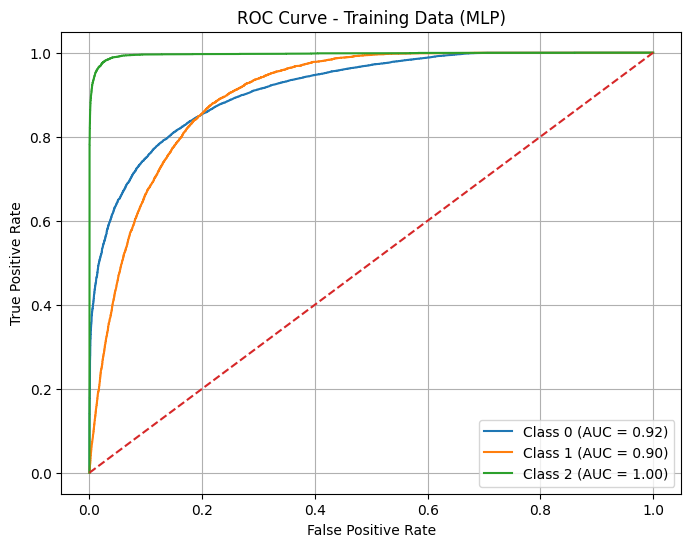

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Predict probabilities on training data
y_train_prob = mlp.predict_proba(X_train)

# Binarize labels (One-vs-Rest)
classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)

# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_train_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Training Data (MLP)")
plt.legend()
plt.grid()
plt.savefig("train_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

## Test ROC Curve

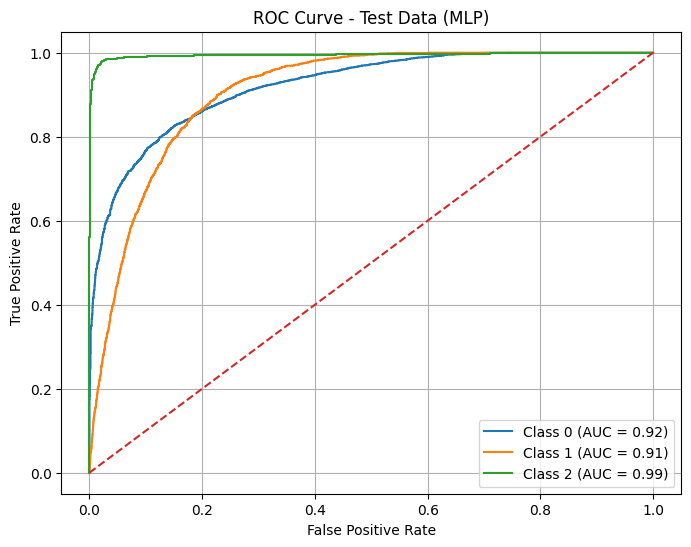

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Predict probabilities on test data
y_test_prob = mlp.predict_proba(X_test)

# Binarize labels (One-vs-Rest)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data (MLP)")
plt.legend()
plt.grid()
plt.savefig("test_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

### Train PR Curve

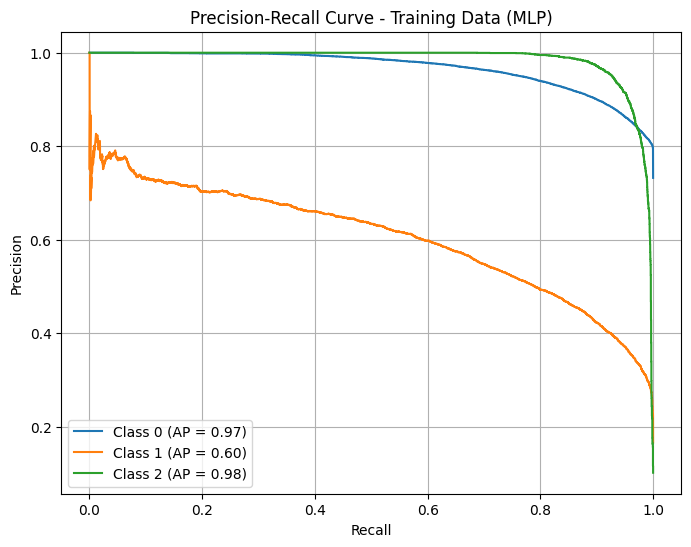

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Predict probabilities on training data
y_train_prob = mlp.predict_proba(X_train)

# Binarize labels (One-vs-Rest)
classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)

# Plot PR curves
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(y_train_bin[:, i], y_train_prob[:, i])
    ap_score = average_precision_score(y_train_bin[:, i], y_train_prob[:, i])
    plt.plot(recall, precision, label=f"Class {classes[i]} (AP = {ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Training Data (MLP)")
plt.legend()
plt.grid()
plt.savefig("train_pr_curve.png", dpi=300, bbox_inches='tight')
plt.show()

## Test PR Curve

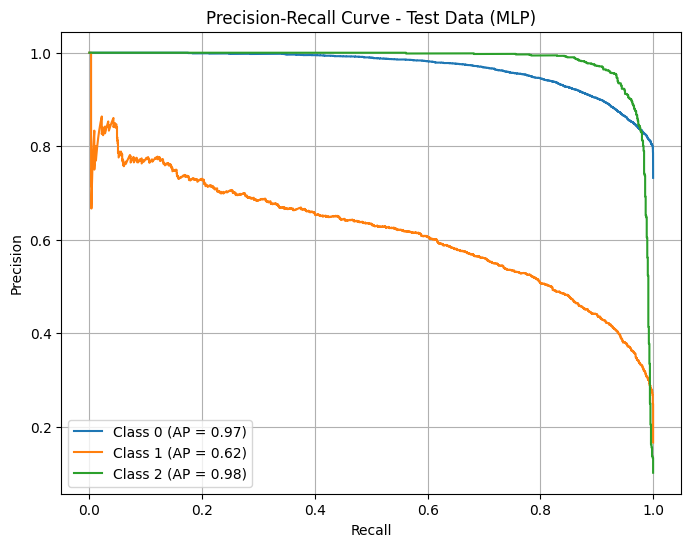

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Predict probabilities on test data
y_test_prob = mlp.predict_proba(X_test)

# Binarize labels (One-vs-Rest)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Plot PR curves
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_test_prob[:, i])
    ap_score = average_precision_score(y_test_bin[:, i], y_test_prob[:, i])
    plt.plot(recall, precision, label=f"Class {classes[i]} (AP = {ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Data (MLP)")
plt.legend()
plt.grid()
plt.savefig("test_pr_curve.png", dpi=300, bbox_inches='tight')
plt.show()

## Training Loss Curve

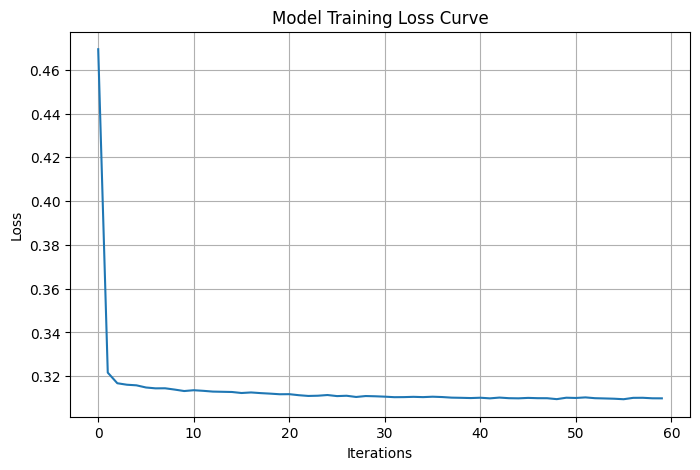

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title("Model Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("Training Loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

## Accuracy Loss curve

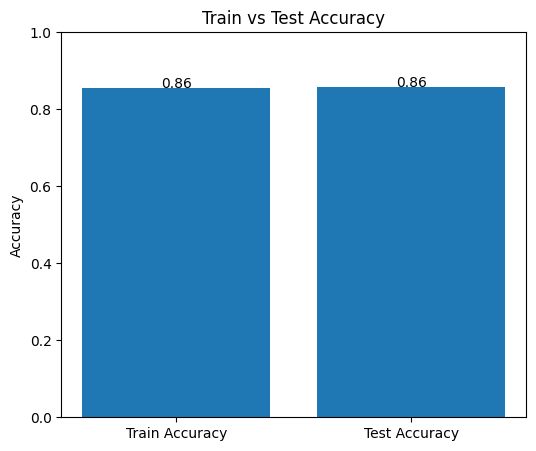

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Predictions
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Plot
plt.figure(figsize=(6,5))
labels = ['Train Accuracy', 'Test Accuracy']
values = [train_acc, test_acc]

plt.bar(labels, values)

plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")

# Show values on bars
for i, v in enumerate(values):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.ylim(0,1)
plt.savefig("accuracy_graph.png", dpi=300, bbox_inches='tight')
plt.show()